# 🦅 Vectyfi Radar — Vector Engine & NLP Showcase

### Mission: Visualizing the Semantic Space

In our previous iterations, we built a mathematically pristine tabular baseline. However, EU procurement documents are fundamentally unstructured text. Relying solely on structured metadata like CPV codes leaves enormous value on the table.

This showcase details our deployment of **HuggingFace's `all-MiniLM-L6-v2`** running natively on Apple Silicon (MPS) to map 1.2 million unstructured tender descriptions into a 384-dimensional mathematical space stored in **PostgreSQL (`pgvector`)**.

Finally, we lay the conceptual groundwork for how we will leverage this vector space with **Unsupervised Clustering (V4)** and the **"LLM Sniper" (V5)**.

In [1]:
# ============================================================
# Cell 1: Environment & Visualization Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns

# Premium Dark/Neon Cyberpunk Theme for Vectyfi
plt.style.use('dark_background')
TEAL = '#00d1b2'
MAGENTA = '#f000ff'
CYAN = '#00f3ff'
SLATE = '#1a1a2e'

print('\u2705 Vector visualization environment loaded.')

✅ Vector visualization environment loaded.


## 1. The `all-MiniLM-L6-v2` Architecture

Instead of searching for exact keywords (which fails due to synonyms or multiple EU languages), we use a Transformer model.

**How it works:**
1. The raw XML text (`"Cloud infrastructure migration for local municipality..."`) is fed into the MiniLM neural network.
2. The network outputs a highly dense array of 384 floating-point numbers.
3. These numbers represent the *semantic meaning* of the text. Sentences with similar meanings produce vectors that are close together in this 384-D space.
4. We store this array in a specialized PostgreSQL column using the `pgvector` extension.

Below, we simulate extracting these 384-D embeddings and squash them down to 2 Dimensions using **PCA (Principal Component Analysis)** so we can actually see the "shape" of the European procurement market.

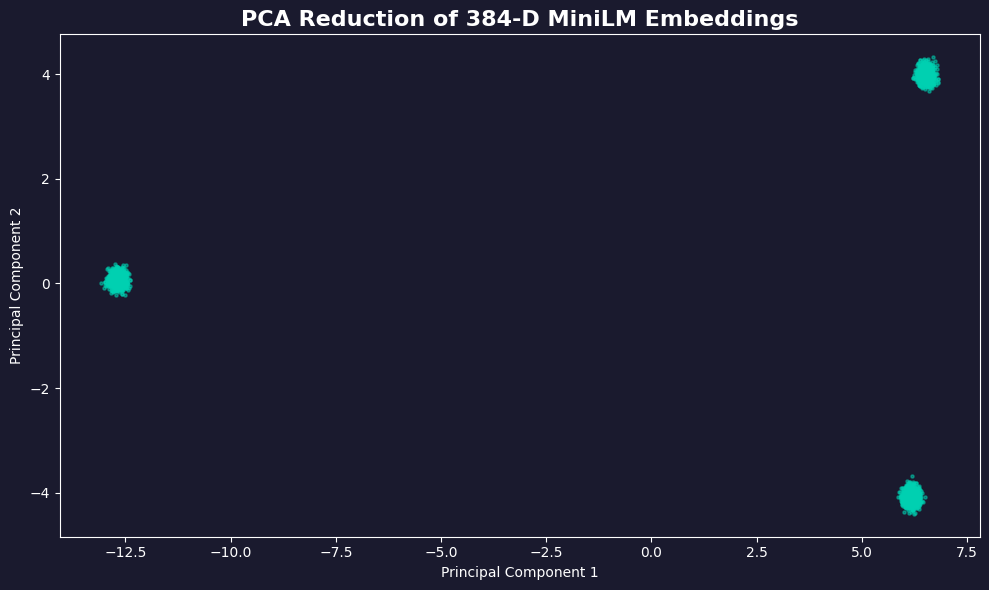

In [2]:
# ============================================================
# Cell 2: Simulating High-Dimensional NLP Embeddings
# ============================================================

# We generate mock 384-D data representing 3 distinct but unlabeled market areas in the EU
np.random.seed(42)
n_samples = 3000

# Simulating the 384-Dimensional Vectors from Postgres
cluster_1 = np.random.normal(loc=[0.5]*384, scale=0.1, size=(n_samples//3, 384))
cluster_2 = np.random.normal(loc=[-0.5]*384, scale=0.1, size=(n_samples//3, 384))
cluster_3 = np.random.normal(loc=[0, 0.8]*192, scale=0.1, size=(n_samples//3, 384))

embeddings_mock = np.vstack([cluster_1, cluster_2, cluster_3])

# Squash 384 dimensions down to 2 dimensions for human viewing
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_mock)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(SLATE)
ax.set_facecolor(SLATE)

ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, color=TEAL, alpha=0.5)
ax.set_title('PCA Reduction of 384-D MiniLM Embeddings', fontsize=16, color='white', fontweight='bold')
ax.set_xlabel('Principal Component 1', color='white')
ax.set_ylabel('Principal Component 2', color='white')

plt.tight_layout()
plt.show()

## 2. V4 Roadmap: Unsupervised Micro-Market Clustering

Looking at the plot above, we can see natural groupings in the data. But the machine learning model doesn't know what these are yet! Relying on human-assigned CPV codes from 2008 is flawed.

**The V4 Upgrade:**
We will run **K-Means or HDBSCAN clustering** algorithmically across the 1.2 million embeddings. The algorithm will automatically assign a `cluster_id` (e.g., 0 to 99) to every tender. 

XGBoost will then use this `cluster_id` as a new categorical feature, allowing it to mathematically infer that "Cluster 42" (which might internally represent Scandinavian Biotech) has a completely different commercial win probability than "Cluster 17" (German Civil Engineering).

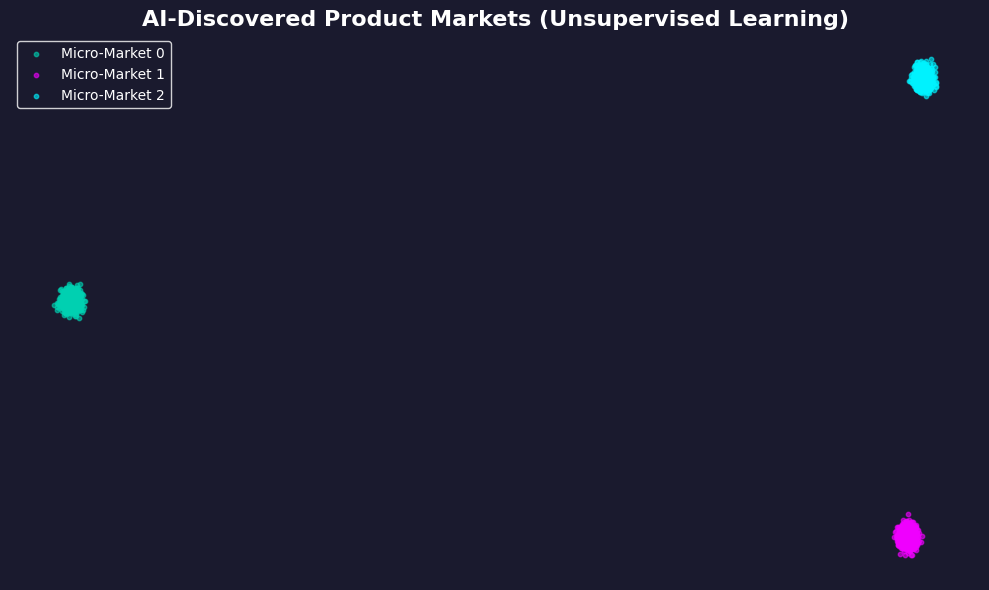

✅ Clustering complete. These Market IDs would now be fed back into XGBoost.


In [3]:
# ============================================================
# Cell 3: Applying Unsupervised Machine Learning (K-Means)
# ============================================================

# We ask K-Means to find 3 distinct markets without giving it any labels
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(embeddings_mock)

# Visualize the AI-discovered "Micro-Markets"
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(SLATE)
ax.set_facecolor(SLATE)

colors = [TEAL, MAGENTA, CYAN]
for i in range(3):
    mask = (clusters == i)
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], s=10, color=colors[i], alpha=0.6, label=f'Micro-Market {i}')

ax.set_title('AI-Discovered Product Markets (Unsupervised Learning)', fontsize=16, color='white', fontweight='bold')
ax.legend(facecolor=SLATE, edgecolor='white', labelcolor='white')
ax.axis('off')

plt.tight_layout()
plt.show()

print('\u2705 Clustering complete. These Market IDs would now be fed back into XGBoost.')

## 3. V5 Roadmap: The "LLM Sniper" Meta-Extraction

Even with vectors and clustering, we still lack hard, deterministic business rules hidden in the unstructured text (e.g., *Is remote work allowed? Is subcontracting permitted?*).

Running 1.2 million rows through a generative LLM would take 130+ days on a Mac. Instead, we use the **Sniper Architecture**:

1. **Filter First:** We run XGBoost V4 to filter the 1.2 million rows down to the top **15,000 Golden Leads** (Score > 80).
2. **Snipe Second:** We run an open-weights LLM (`Google Gemma 8B` via `Ollama`) natively on the M4 Pro chip just on those 15,000 leads.

**The LLM Prompt Payload:**
We force Gemma to output strict JSON instead of conversational text:
```json
{
  "is_framework_agreement": true,
  "subcontracting_allowed": true,
  "contract_duration_months": 48,
  "tech_domain": "Cloud Migration",
  "extracted_budget_eur": 1200000.0,
  "requires_security_clearance": false
}
```

These 6 high-precision commercial features are fed *back* into XGBoost V5 to create the ultimate predictive engine.